In [25]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
# Store some patterns
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

In [27]:
def hopfield_retrieve(query, X, beta=1.0):
    # similarity between query and all stored patterns
    similarities = X @ query
    
    # softmax weighted sum of patterns
    weights = F.softmax(beta * similarities, dim=0)
    retrieved = X.T @ weights
    
    return retrieved

In [ ]:
# Pick a pattern and corrupt it
original = X[0]
noise = torch.randn(dim, device=device) * 0.3
query = F.normalize(original + noise, dim=0)

# Retrieve
retrieved = hopfield_retrieve(query, X, beta=4.0)

# How close did we get back?
similarity = F.cosine_similarity(retrieved.unsqueeze(0), original.unsqueeze(0))
print(f"Similarity to original: {similarity.item():.4f}")

Similarity to original: 0.8947


In [28]:
# Pattern strengths - this is the slow variable
w = torch.ones(n_patterns, device=device)

def hopfield_retrieve_weighted(query, X, w, beta=4.0):
    similarities = X @ query
    # bias similarities by strength in log space
    biased = beta * similarities + torch.log(w)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

In [42]:
increment = 0.1
decay = 0.005

def update_weights(w, retrieval_weights):
    # decay everything toward 1
    w = w + decay * (1 - w)
    # strengthen winners proportional to how much they contributed
    w = w + increment * retrieval_weights
    return w

In [ ]:
n_steps = 1000
w = torch.ones(n_patterns, device=device)
# track strength history so we can plot it
w_history = torch.zeros(n_steps, n_patterns)

for step in range(n_steps):
    # biased sampling - pattern 0 gets visited 60% of the time
    probs = torch.tensor([0.6, 0.1, 0.1, 0.1, 0.1])
    idx = torch.multinomial(probs, 1).item()
    query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)
    
    # retrieve
    retrieved, retrieval_weights = hopfield_retrieve_weighted(query, X, w, beta=4.0)
    
    # update strengths
    w = update_weights(w, retrieval_weights)
    
    # record
    w_history[step] = w

print("final strengths:", w)

final strengths: tensor([8.5789, 1.6984, 1.5943, 1.4959, 1.6322], device='cuda:0')


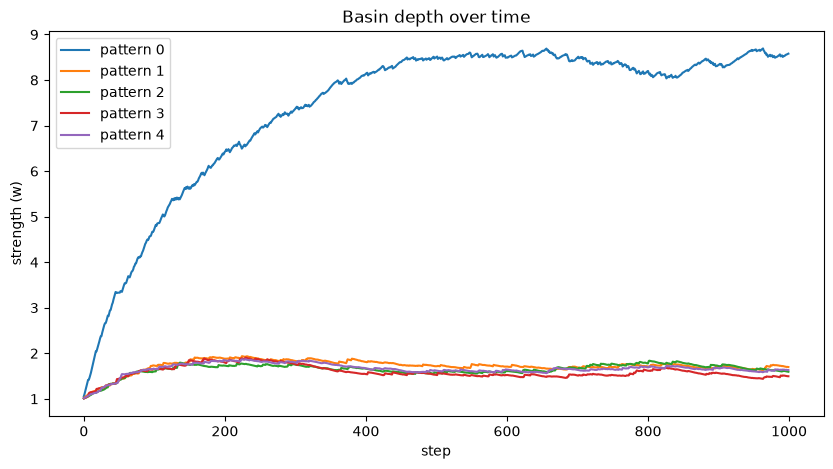

In [37]:
plt.figure(figsize=(10, 5))
for i in range(n_patterns):
    plt.plot(w_history[:, i].cpu().numpy(), label=f'pattern {i}')

plt.xlabel('step')
plt.ylabel('strength (w)')
plt.title('Basin depth over time')
plt.legend()
plt.show()

In [38]:
ambiguous = F.normalize(X[0] + X[1], dim=0)
print(hopfield_retrieve_weighted(ambiguous, X, w, beta=4.0))
w = torch.ones(n_patterns, device=device)
print(hopfield_retrieve_weighted(ambiguous, X, w, beta=4.0))


(tensor([ 0.0454,  0.2009, -0.0039,  0.0582, -0.2093,  0.0798, -0.0670, -0.0728,
         0.0638, -0.0778, -0.1717,  0.0076, -0.0371,  0.0458, -0.1283,  0.2126,
        -0.0881,  0.0555,  0.0662, -0.0149,  0.1428, -0.0652, -0.0197,  0.1647,
        -0.0210, -0.1465,  0.2380, -0.0670, -0.0153, -0.1396, -0.1858, -0.1584,
         0.1028,  0.1564,  0.0954,  0.0277, -0.2073,  0.0630,  0.2109, -0.0370,
         0.0990, -0.0248, -0.0112, -0.0051,  0.0233, -0.0644, -0.1291, -0.0529,
        -0.0201, -0.0580, -0.0979,  0.0495,  0.0098, -0.0181,  0.1188, -0.1354,
        -0.0206, -0.0742,  0.0438, -0.0677,  0.1188, -0.1170,  0.0213, -0.0619],
       device='cuda:0'), tensor([0.8165, 0.1616, 0.0044, 0.0080, 0.0095], device='cuda:0'))
(tensor([ 0.0838,  0.0567,  0.0306, -0.0377, -0.1378,  0.0719, -0.0362, -0.0108,
         0.0566,  0.0843, -0.0927,  0.0957, -0.0847,  0.0842, -0.0991,  0.1637,
        -0.0808, -0.0060, -0.0019, -0.0346,  0.0506, -0.0634,  0.0055,  0.1181,
         0.0186, -0.1414,

Final strengths: tensor([ 4.2620,  5.1138, 10.0116,  2.6974,  2.8663], device='cuda:0')


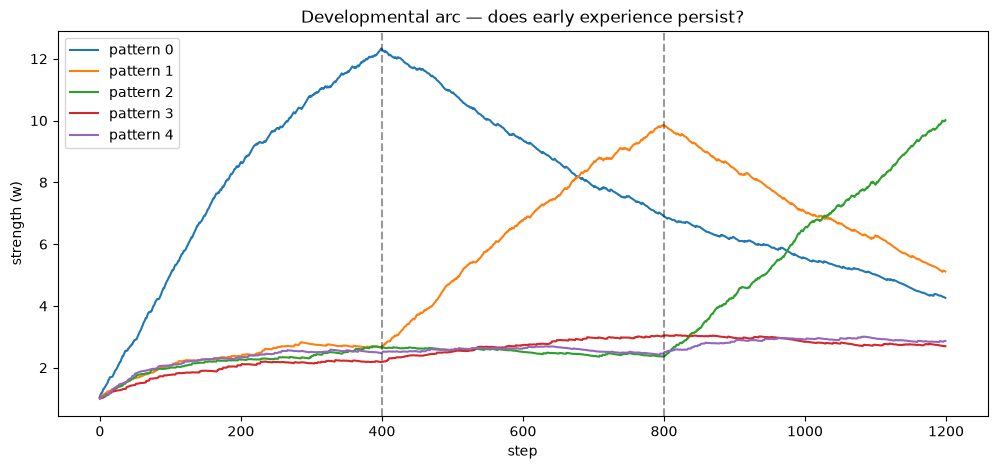

In [43]:
n_steps_per_phase = 400
n_phases = 3
n_steps = n_steps_per_phase * n_phases

w = torch.ones(n_patterns, device=device)
w_history = torch.zeros(n_steps, n_patterns)

phase_probs = [
    torch.tensor([0.7, 0.075, 0.075, 0.075, 0.075]),  # phase 1: pattern 0
    torch.tensor([0.075, 0.7, 0.075, 0.075, 0.075]),  # phase 2: pattern 1
    torch.tensor([0.075, 0.075, 0.7, 0.075, 0.075]),  # phase 3: pattern 2
]

for step in range(n_steps):
    phase = step // n_steps_per_phase
    probs = phase_probs[phase]

    idx = torch.multinomial(probs, 1).item()
    query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

    retrieved, retrieval_weights = hopfield_retrieve_weighted(query, X, w, beta=4.0)
    w = update_weights(w, retrieval_weights)
    w_history[step] = w

print("Final strengths:", w)

plt.figure(figsize=(12, 5))
for i in range(n_patterns):
    plt.plot(w_history[:, i].cpu().numpy(), label=f'pattern {i}')

# phase boundaries
for phase_end in [400, 800]:
    plt.axvline(x=phase_end, color='black', linestyle='--', alpha=0.4)

plt.xlabel('step')
plt.ylabel('strength (w)')
plt.title('Developmental arc — does early experience persist?')
plt.legend()
plt.show()